# Download US Census Tract Data (ACS 2024)

Download Census tract-level statistics for computing visitor diversity:
- **Median household income** - socioeconomic status
- **Nativity/Foreign-born population** - birth background diversity
- **Race/ethnicity breakdown**

Data source: American Community Survey (ACS) 5-Year Estimates 2024

This script downloads data for ALL US states and territories, then filters to study cities.

In [1]:
%cd /workspace

/workspace


In [2]:
import requests
import pandas as pd
import time
from pathlib import Path
from functools import reduce
import os

## 1. Configuration

In [26]:
# =========================
# Config
# =========================
ACS_YEAR = 2024
BASE_URL = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5"

OUTPUT_DIR = Path("dbs/us_census")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Put your Census API key here if you have one.
# Get free key from: https://api.census.gov/data/key_signup.html
# Without a key, Census documents a per-IP daily query limit.
API_KEY = os.getenv('CENSUS_API_KEY', None)

print(f"ACS Year: {ACS_YEAR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"API Key: {'Configured' if API_KEY else 'Not set (will use rate-limited access)'}")

ACS Year: 2024
Output directory: dbs/us_census
API Key: Configured


In [4]:
# All states + DC + PR.
# You can shrink this list for testing.
STATE_FIPS = [
    "01","02","04","05","06","08","09","10","11","12","13","15","16","17","18","19",
    "20","21","22","23","24","25","26","27","28","29","30","31","32","33","34","35",
    "36","37","38","39","40","41","42","44","45","46","47","48","49","50","51","53",
    "54","55","56","72"
]

print(f"Total states/territories to download: {len(STATE_FIPS)}")

Total states/territories to download: 52


## 2. Variables Definition

In [5]:
# =========================
# Variables
# =========================
VARIABLES = {
    # Income
    "B19013_001E": "median_household_income",

    # Total population
    "B01003_001E": "total_population",

    # Nativity
    "B05002_001E": "nativity_total",
    "B05002_002E": "native_born",
    "B05002_013E": "foreign_born",

    # Foreign-born by region of birth
    "B05006_001E": "foreign_born_total",
    "B05006_002E": "foreign_europe",
    "B05006_047E": "foreign_asia",
    "B05006_123E": "foreign_africa",
    "B05006_138E": "foreign_oceania",
    "B05006_142E": "foreign_americas",

    # Race / ethnicity
    "B03002_001E": "race_total",
    "B03002_003E": "race_white_alone",
    "B03002_004E": "race_black_alone",
    "B03002_006E": "race_asian_alone",
    "B03002_012E": "race_hispanic_latino",
}

print(f"Variables to download: {len(VARIABLES)}")
for code, name in VARIABLES.items():
    print(f"  {code}: {name}")

Variables to download: 16
  B19013_001E: median_household_income
  B01003_001E: total_population
  B05002_001E: nativity_total
  B05002_002E: native_born
  B05002_013E: foreign_born
  B05006_001E: foreign_born_total
  B05006_002E: foreign_europe
  B05006_047E: foreign_asia
  B05006_123E: foreign_africa
  B05006_138E: foreign_oceania
  B05006_142E: foreign_americas
  B03002_001E: race_total
  B03002_003E: race_white_alone
  B03002_004E: race_black_alone
  B03002_006E: race_asian_alone
  B03002_012E: race_hispanic_latino


## 3. Helper Functions

In [6]:
def chunk_list(items, chunk_size):
    """Split a list into chunks of specified size."""
    for i in range(0, len(items), chunk_size):
        yield items[i:i + chunk_size]

In [7]:
def safe_get_json(url, params, max_retries=4, sleep_seconds=1.5):
    """
    Census may return status 200 with a text error message instead of valid JSON.
    So we inspect the body before trusting response.json().
    """
    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            r = requests.get(url, params=params, timeout=60)

            # Helpful when debugging one bad request
            if attempt == 1:
                print(f"\nURL: {r.url[:100]}...")
                print(f"Status: {r.status_code}")

            r.raise_for_status()

            text = r.text.strip()
            if not text:
                raise ValueError("Empty response body")

            # Census text errors often begin with "error:"
            if text.lower().startswith("error"):
                raise ValueError(f"Census API text error: {text[:500]}")

            try:
                return r.json()
            except ValueError as e:
                raise ValueError(f"Non-JSON response: {text[:500]}") from e

        except Exception as e:
            last_error = e
            print(f"Attempt {attempt}/{max_retries} failed: {e}")
            if attempt < max_retries:
                time.sleep(sleep_seconds * attempt)

    raise last_error

In [8]:
def validate_variables(variables):
    """
    Check variable names against the official ACS variables endpoint.
    """
    variables_url = f"{BASE_URL}/variables.json"
    print(f"Validating variables against {variables_url}")
    
    meta = safe_get_json(variables_url, params={})
    valid = set(meta["variables"].keys())

    requested = set(variables.keys())
    missing = sorted(requested - valid)
    present = sorted(requested & valid)

    print(f"\nValidated variables: {len(present)} found, {len(missing)} missing")

    if missing:
        print("Missing variables:")
        for v in missing:
            print("  ", v)

    return present, missing

In [9]:
def fetch_state_tract_data(state_fips, variables_subset, api_key=None):
    """
    Pull tract data for one state for a subset of variables.
    This is usually faster than county-by-county.
    """
    get_vars = ["NAME"] + variables_subset
    params = {
        "get": ",".join(get_vars),
        "for": "tract:*",
        "in": f"state:{state_fips}",
    }
    if api_key:
        params["key"] = api_key

    data = safe_get_json(BASE_URL, params=params)

    if not isinstance(data, list) or len(data) <= 1:
        return pd.DataFrame()

    df = pd.DataFrame(data[1:], columns=data[0])
    return df

In [10]:
def fetch_all_states(variables, state_fips_list, api_key=None, vars_per_call=45):
    """
    vars_per_call=45 leaves room below the 50-variable API query limit,
    since NAME and geography columns are also in the response.
    """
    variable_codes = list(variables.keys())

    # Keep comfortably under the documented 50-variable query limit.
    chunks = list(chunk_list(variable_codes, vars_per_call))
    print(f"\nTotal variables: {len(variable_codes)}")
    print(f"Variable chunks: {len(chunks)}")

    all_states = []

    for state in state_fips_list:
        print(f"\n===== State {state} =====")
        state_parts = []

        for i, var_chunk in enumerate(chunks, start=1):
            print(f"  Fetching chunk {i}/{len(chunks)} with {len(var_chunk)} variables")
            part = fetch_state_tract_data(state, var_chunk, api_key=api_key)

            if part.empty:
                print(f"  Warning: no data returned for state {state}, chunk {i}")
                continue

            # Merge key
            part["GEOID"] = part["state"] + part["county"] + part["tract"]
            state_parts.append(part)

            # Small pause to be gentle with the API
            time.sleep(0.25)

        if not state_parts:
            print(f"  No data collected for state {state}")
            continue

        # Merge all chunks on shared geography columns
        def merge_two(left, right):
            overlap = [c for c in ["GEOID", "NAME", "state", "county", "tract"] if c in left.columns and c in right.columns]
            right_nonoverlap = [c for c in right.columns if c not in overlap]
            return left.merge(right[overlap + right_nonoverlap], on=overlap, how="outer")

        state_df = reduce(merge_two, state_parts)

        # Rename variables to friendly names
        rename_map = {k: v for k, v in variables.items() if k in state_df.columns}
        state_df = state_df.rename(columns=rename_map)

        # Convert estimate columns to numeric
        for col in state_df.columns:
            if col in rename_map.values():
                state_df[col] = pd.to_numeric(state_df[col], errors="coerce")

        # Save each state separately
        out_fp = OUTPUT_DIR / f"acs{ACS_YEAR}_tracts_state_{state}.parquet"
        state_df.to_parquet(out_fp, index=False)
        print(f"  Saved {len(state_df):,} rows -> {out_fp.name}")

        all_states.append(state_df)

    if not all_states:
        return pd.DataFrame()

    full_df = pd.concat(all_states, ignore_index=True)
    full_out = OUTPUT_DIR / f"acs{ACS_YEAR}_tracts_all_states.parquet"
    full_df.to_parquet(full_out, index=False)
    print(f"\nSaved full file: {full_out.name} with {len(full_df):,} rows")

    return full_df

## 4. Validate Variables

In [11]:
present, missing = validate_variables(VARIABLES)

if missing:
    print("\nSome requested variables were not found in this dataset/year.")
    print("Proceeding only with valid variables.\n")

valid_variables = {k: VARIABLES[k] for k in VARIABLES if k in present}
print(f"\nValid variables to download: {len(valid_variables)}")

Validating variables against https://api.census.gov/data/2024/acs/acs5/variables.json

URL: https://api.census.gov/data/2024/acs/acs5/variables.json...
Status: 200

Validated variables: 16 found, 0 missing

Valid variables to download: 16


## 5. Download All States

In [29]:
df = fetch_all_states(
    variables=valid_variables,
    state_fips_list=STATE_FIPS,
    api_key=API_KEY,
    vars_per_call=45
)

print("\nDone.")
print(f"Total rows: {len(df):,}")
df.head()


Total variables: 16
Variable chunks: 1

===== State 01 =====
  Fetching chunk 1/1 with 16 variables

URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB19013_001E%2CB01003_001E%2CB05002_001E%2CB0500...
Status: 200
  Saved 1,437 rows -> acs2024_tracts_state_01.parquet

===== State 02 =====
  Fetching chunk 1/1 with 16 variables

URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB19013_001E%2CB01003_001E%2CB05002_001E%2CB0500...
Status: 200
  Saved 177 rows -> acs2024_tracts_state_02.parquet

===== State 04 =====
  Fetching chunk 1/1 with 16 variables

URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB19013_001E%2CB01003_001E%2CB05002_001E%2CB0500...
Status: 200
  Saved 1,765 rows -> acs2024_tracts_state_04.parquet

===== State 05 =====
  Fetching chunk 1/1 with 16 variables

URL: https://api.census.gov/data/2024/acs/acs5?get=NAME%2CB19013_001E%2CB01003_001E%2CB05002_001E%2CB0500...
Status: 200
  Saved 823 rows -> acs2024_tracts_state_05.parquet

===== State 06 

,NAME,median_household_income,total_population,nativity_total,native_born,foreign_born,foreign_born_total,foreign_europe,foreign_asia,foreign_africa,...,foreign_americas,race_total,race_white_alone,race_black_alone,race_asian_alone,race_hispanic_latino,state,county,tract,GEOID
0,Census Tract 201; Autauga County; Alabama,63237,1781,1781,1630,151,151.0,0.0,0.0,0.0,...,0.0,1781,1185,144,79,211,01,001,020100,01001020100
1,Census Tract 202; Autauga County; Alabama,61229,1941,1941,1907,34,34.0,7.0,27.0,0.0,...,0.0,1941,627,1213,27,14,01,001,020200,01001020200
2,Census Tract 203; Autauga County; Alabama,63939,3425,3425,3406,19,19.0,0.0,0.0,0.0,...,0.0,3425,2197,941,0,134,01,001,020300,01001020300
3,Census Tract 204; Autauga County; Alabama,69348,3948,3948,3869,79,79.0,47.0,32.0,0.0,...,0.0,3948,3478,204,32,70,01,001,020400,01001020400
4,Census Tract 205.01; Autauga County; Alabama,88965,4444,4444,4070,374,374.0,304.0,56.0,0.0,...,0.0,4444,3488,466,97,268,01,001,020501,01001020501


## 6. Explore Downloaded Data

In [13]:
print("Columns:")
print(df.columns.tolist())

print(f"\nShape: {df.shape}")
print(f"\nStates covered: {df['state'].nunique()}")

Columns:
['NAME', 'median_household_income', 'total_population', 'nativity_total', 'native_born', 'foreign_born', 'foreign_born_total', 'foreign_europe', 'foreign_asia', 'foreign_africa', 'foreign_oceania', 'foreign_americas', 'race_total', 'race_white_alone', 'race_black_alone', 'race_asian_alone', 'race_hispanic_latino', 'state', 'county', 'tract', 'GEOID']

Shape: (85382, 21)

States covered: 52


In [14]:
# Summary statistics
numeric_cols = [c for c in df.columns if c in valid_variables.values()]
df[numeric_cols].describe()

,median_household_income,total_population,nativity_total,native_born,foreign_born,foreign_born_total,foreign_europe,foreign_asia,foreign_africa,foreign_oceania,foreign_americas,race_total,race_white_alone,race_black_alone,race_asian_alone,race_hispanic_latino
count,8.538200e+04,85382.000000,85382.000000,85382.000000,85382.000000,84401.000000,84401.000000,84401.000000,84401.000000,84401.000000,84401.000000,85382.000000,85382.000000,85382.000000,85382.000000,85382.000000
mean,-1.204954e+07,3959.607751,3959.607751,3404.398855,555.208896,560.621521,57.498951,172.731911,1.175590,294.097617,0.582837,3959.607751,2251.385058,467.153053,230.497751,795.320372
std,8.912938e+07,1832.366155,1832.366155,1611.835626,685.416073,687.376308,106.271349,347.774487,14.429762,484.781526,6.771444,1832.366155,1552.470990,769.491440,485.912339,1110.337160
min,-6.666667e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.631425e+04,2707.000000,2707.000000,2295.000000,88.000000,90.000000,0.000000,4.000000,0.000000,24.000000,0.000000,2707.000000,1057.000000,23.000000,4.000000,115.000000
50%,7.625000e+04,3767.000000,3767.000000,3221.000000,292.000000,298.000000,21.000000,46.000000,0.000000,101.000000,0.000000,3767.000000,2103.000000,142.000000,56.000000,348.000000
75%,1.038568e+05,4974.000000,4974.000000,4301.000000,774.000000,783.000000,68.000000,178.000000,0.000000,334.000000,0.000000,4974.000000,3221.000000,562.000000,228.000000,979.000000
max,2.500010e+05,44364.000000,44364.000000,37859.000000,15545.000000,15545.000000,3880.000000,9405.000000,1113.000000,8052.000000,450.000000,44364.000000,20381.000000,9296.000000,12362.000000,19246.000000


In [15]:
# Check for missing values
print("Missing values:")
missing_counts = df[numeric_cols].isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(1)
pd.DataFrame({'missing': missing_counts, 'pct': missing_pct})

Missing values:


,missing,pct
median_household_income,0,0.0
total_population,0,0.0
nativity_total,0,0.0
native_born,0,0.0
foreign_born,0,0.0
foreign_born_total,981,1.1
foreign_europe,981,1.1
foreign_asia,981,1.1
foreign_africa,981,1.1
foreign_oceania,981,1.1


## 7. Filter to Study Cities

In [16]:
# MSA county definitions for study cities
MSA_COUNTIES = {
    'new_york': {
        'counties': [
            '36005', '36047', '36061', '36081', '36085', '36059', '36103',
            '36119', '36087', '36079', '34003', '34013', '34017', '34019',
            '34023', '34025', '34027', '34029', '34031', '34035', '34037',
            '34039', '42103',
        ]
    },
    'chicago': {
        'counties': [
            '17031', '17043', '17089', '17093', '17097', '17111', '17197',
            '17063', '18073', '18089', '18111', '18127', '55059',
        ]
    },
    'washington_dc': {
        'counties': [
            '11001', '51013', '51059', '51107', '51153', '51510', '51600',
            '51610', '51683', '51685', '51061', '51177', '51179', '51187',
            '24009', '24017', '24021', '24031', '24033', '54037',
        ]
    },
    'houston': {
        'counties': [
            '48015', '48039', '48071', '48157', '48167', '48201', '48291',
            '48339', '48473',
        ]
    },
    'atlanta': {
        'counties': [
            '13013', '13015', '13035', '13045', '13057', '13063', '13067',
            '13077', '13085', '13089', '13097', '13113', '13117', '13121',
            '13135', '13143', '13149', '13151', '13159', '13171', '13199',
            '13211', '13217', '13223', '13227', '13231', '13247', '13255',
            '13297',
        ]
    },
    'phoenix': {
        'counties': ['04013', '04021'],
    }
}

# Build county FIPS lookup
all_study_counties = set()
county_to_city = {}
for city, info in MSA_COUNTIES.items():
    for county in info['counties']:
        all_study_counties.add(county)
        county_to_city[county] = city

print(f"Study counties: {len(all_study_counties)}")

Study counties: 96


In [17]:
# Create county FIPS from state + county
df['county_fips'] = df['state'] + df['county']

# Filter to study cities
df_study = df[df['county_fips'].isin(all_study_counties)].copy()
df_study['city'] = df_study['county_fips'].map(county_to_city)

print(f"Tracts in study cities: {len(df_study):,}")
print(f"\nTracts per city:")
print(df_study.groupby('city').size())

Tracts in study cities: 12,921

Tracts per city:
city
atlanta          1500
chicago          2312
houston          1606
new_york         4939
phoenix          1104
washington_dc    1460
dtype: int64


## 8. Compute Derived Variables

In [18]:
# Compute percentages
df_study['pct_foreign_born'] = (df_study['foreign_born'] / df_study['nativity_total'] * 100).round(2)
df_study['pct_native_born'] = (df_study['native_born'] / df_study['nativity_total'] * 100).round(2)

# Race/ethnicity percentages
df_study['pct_white'] = (df_study['race_white_alone'] / df_study['race_total'] * 100).round(2)
df_study['pct_black'] = (df_study['race_black_alone'] / df_study['race_total'] * 100).round(2)
df_study['pct_asian'] = (df_study['race_asian_alone'] / df_study['race_total'] * 100).round(2)
df_study['pct_hispanic'] = (df_study['race_hispanic_latino'] / df_study['race_total'] * 100).round(2)

# Foreign-born by region (of foreign-born population)
df_study['pct_foreign_europe'] = (df_study['foreign_europe'] / df_study['foreign_born_total'] * 100).round(2)
df_study['pct_foreign_asia'] = (df_study['foreign_asia'] / df_study['foreign_born_total'] * 100).round(2)
df_study['pct_foreign_africa'] = (df_study['foreign_africa'] / df_study['foreign_born_total'] * 100).round(2)
df_study['pct_foreign_americas'] = (df_study['foreign_americas'] / df_study['foreign_born_total'] * 100).round(2)

# Income quintiles (within each city)
df_study['income_quintile'] = df_study.groupby('city')['median_household_income'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 5, labels=['Q1_lowest', 'Q2', 'Q3', 'Q4', 'Q5_highest'])
)

df_study.head()

,NAME,median_household_income,total_population,nativity_total,native_born,foreign_born,foreign_born_total,foreign_europe,foreign_asia,foreign_africa,...,pct_native_born,pct_white,pct_black,pct_asian,pct_hispanic,pct_foreign_europe,pct_foreign_asia,pct_foreign_africa,pct_foreign_americas,income_quintile
1749,Census Tract 101.02; Maricopa County; Arizona,201667,6525,6525,6045,480,480.0,122.0,46.0,0.0,...,92.64,81.41,2.64,1.69,8.11,25.42,9.58,0.0,0.0,Q5_highest
1750,Census Tract 101.03; Maricopa County; Arizona,143478,3842,3842,3367,475,475.0,206.0,17.0,0.0,...,87.64,84.64,0.70,0.18,10.59,43.37,3.58,0.0,0.0,Q5_highest
1751,Census Tract 101.04; Maricopa County; Arizona,142356,3381,3381,3220,161,161.0,52.0,0.0,0.0,...,95.24,93.32,0.59,0.27,2.22,32.30,0.00,0.0,0.0,Q5_highest
1752,Census Tract 304.01; Maricopa County; Arizona,150943,4774,4774,4289,485,485.0,139.0,86.0,0.0,...,89.84,91.12,1.82,2.41,1.76,28.66,17.73,0.0,0.0,Q5_highest
1753,Census Tract 304.02; Maricopa County; Arizona,106801,4237,4237,4002,235,235.0,80.0,90.0,0.0,...,94.45,90.11,0.00,1.42,4.86,34.04,38.30,0.0,0.0,Q4


## 9. Visualize by City

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Summary by city
city_summary = df_study.groupby('city').agg(
    tracts=('GEOID', 'count'),
    total_pop=('total_population', 'sum'),
    median_income=('median_household_income', 'median'),
    mean_pct_foreign=('pct_foreign_born', 'mean'),
    mean_pct_hispanic=('pct_hispanic', 'mean'),
    mean_pct_black=('pct_black', 'mean'),
    mean_pct_asian=('pct_asian', 'mean'),
).round(1)

city_summary

,tracts,total_pop,median_income,mean_pct_foreign,mean_pct_hispanic,mean_pct_black,mean_pct_asian
city,,,,,,,
atlanta,1500,6241443,89100.0,15.0,12.4,34.2,6.4
chicago,2312,9439330,87248.5,17.6,23.6,19.5,6.7
houston,1606,7414347,76853.5,24.7,39.5,17.1,7.5
new_york,4939,19781579,97750.0,30.5,25.0,15.9,12.1
phoenix,1104,5028754,86415.0,14.0,30.6,5.2,4.1
washington_dc,1460,6306777,130377.0,23.3,17.1,24.3,10.2


In [ ]:
# Income distribution by city
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, city in enumerate(MSA_COUNTIES.keys()):
    city_data = df_study[df_study['city'] == city]['median_household_income'].dropna()
    axes[i].hist(city_data / 1000, bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(city_data.median() / 1000, color='red', linestyle='--', 
                    label=f'Median: ${city_data.median()/1000:.0f}K')
    axes[i].set_title(city.replace('_', ' ').title())
    axes[i].set_xlabel('Median HH Income ($K)')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Tract-Level Income Distribution by City', y=1.02, fontsize=14)
plt.show()

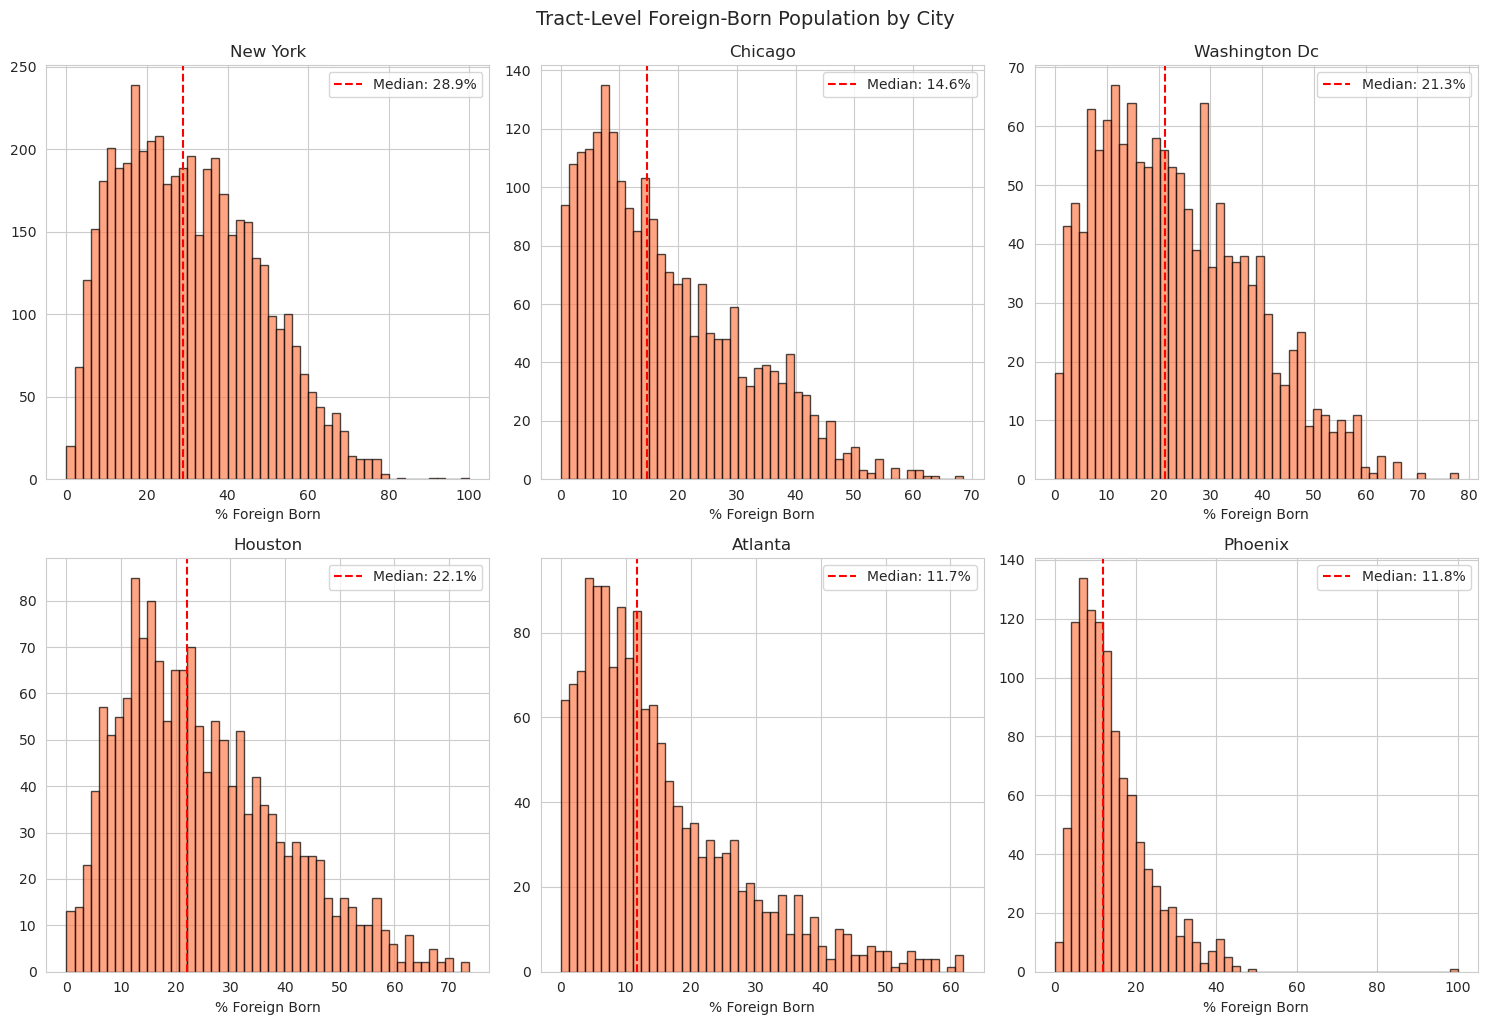

In [21]:
# Foreign-born percentage distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, city in enumerate(MSA_COUNTIES.keys()):
    city_data = df_study[df_study['city'] == city]['pct_foreign_born'].dropna()
    axes[i].hist(city_data, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[i].axvline(city_data.median(), color='red', linestyle='--', 
                    label=f'Median: {city_data.median():.1f}%')
    axes[i].set_title(city.replace('_', ' ').title())
    axes[i].set_xlabel('% Foreign Born')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Tract-Level Foreign-Born Population by City', y=1.02, fontsize=14)
plt.show()

## 10. Save Study City Data

In [27]:
# Save study city tracts
study_file = OUTPUT_DIR / f'acs{ACS_YEAR}_tracts_study_cities.parquet'
df_study.to_parquet(study_file, index=False)
print(f"Saved: {study_file}")
print(f"Size: {study_file.stat().st_size / 1e6:.1f} MB")

# Also save as CSV
csv_file = OUTPUT_DIR / f'acs{ACS_YEAR}_tracts_study_cities.csv'
df_study.to_csv(csv_file, index=False)
print(f"Saved: {csv_file}")

Saved: dbs/us_census/acs2024_tracts_study_cities.parquet
Size: 1.1 MB
Saved: dbs/us_census/acs2024_tracts_study_cities.csv


In [28]:
# Create slim lookup table for joining with visitor data
tract_lookup = df_study[[
    'GEOID', 'city', 'state', 'county',
    'total_population', 'median_household_income',
    'pct_foreign_born', 'pct_native_born',
    'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic',
    'income_quintile'
]].copy()

tract_lookup = tract_lookup.rename(columns={'GEOID': 'tract_geoid'})

lookup_file = OUTPUT_DIR / 'tract_lookup.parquet'
tract_lookup.to_parquet(lookup_file, index=False)
print(f"Saved: {lookup_file}")
print(f"\nTract lookup table: {len(tract_lookup):,} tracts")
tract_lookup.head()

Saved: dbs/us_census/tract_lookup.parquet

Tract lookup table: 12,921 tracts


,tract_geoid,city,state,county,total_population,median_household_income,pct_foreign_born,pct_native_born,pct_white,pct_black,pct_asian,pct_hispanic,income_quintile
1749,04013010102,phoenix,04,013,6525,201667,7.36,92.64,81.41,2.64,1.69,8.11,Q5_highest
1750,04013010103,phoenix,04,013,3842,143478,12.36,87.64,84.64,0.70,0.18,10.59,Q5_highest
1751,04013010104,phoenix,04,013,3381,142356,4.76,95.24,93.32,0.59,0.27,2.22,Q5_highest
1752,04013030401,phoenix,04,013,4774,150943,10.16,89.84,91.12,1.82,2.41,1.76,Q5_highest
1753,04013030402,phoenix,04,013,4237,106801,5.55,94.45,90.11,0.00,1.42,4.86,Q4


## 11. Summary

In [24]:
print("=" * 60)
print("US CENSUS TRACT DATA SUMMARY")
print("=" * 60)

print(f"""
DATA SOURCE: ACS 5-Year Estimates {ACS_YEAR}

FULL DOWNLOAD:
  States/territories: {len(STATE_FIPS)}
  Total tracts: {len(df):,}

STUDY CITIES:
  Cities: {df_study['city'].nunique()}
  Tracts: {len(df_study):,}
  Total population: {df_study['total_population'].sum():,.0f}

KEY VARIABLES:
  - Median household income
  - Foreign-born percentage
  - Race/ethnicity breakdown (White, Black, Asian, Hispanic)
  - Foreign-born by region of origin
  - Income quintiles (city-specific)

OUTPUT FILES:
  - acs{ACS_YEAR}_tracts_all_states.parquet (full US data)
  - acs{ACS_YEAR}_tracts_study_cities.parquet (study cities only)
  - tract_lookup.parquet (slim lookup table)

USAGE:
  To join with VISITOR_HOME_CBGS:
  1. Extract tract_geoid from CBG (first 11 digits)
  2. Join with tract_lookup on tract_geoid
  3. Compute visitor diversity using income/nativity data
""")

US CENSUS TRACT DATA SUMMARY

DATA SOURCE: ACS 5-Year Estimates 2024

FULL DOWNLOAD:
  States/territories: 52
  Total tracts: 85,382

STUDY CITIES:
  Cities: 6
  Tracts: 12,921
  Total population: 54,212,230

KEY VARIABLES:
  - Median household income
  - Foreign-born percentage
  - Race/ethnicity breakdown (White, Black, Asian, Hispanic)
  - Foreign-born by region of origin
  - Income quintiles (city-specific)

OUTPUT FILES:
  - acs2024_tracts_all_states.parquet (full US data)
  - acs2024_tracts_study_cities.parquet (study cities only)
  - tract_lookup.parquet (slim lookup table)

USAGE:
  To join with VISITOR_HOME_CBGS:
  1. Extract tract_geoid from CBG (first 11 digits)
  2. Join with tract_lookup on tract_geoid
  3. Compute visitor diversity using income/nativity data

